In [26]:
import os
import nibabel as nib
import numpy as np
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from glob import glob
import cv2
from medpy.metric.binary import hd95
from scipy.ndimage import label

In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA version PyTorch was built with:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())

Torch version: 2.7.1+cu118
CUDA version PyTorch was built with: 11.8
Is CUDA available: True


In [3]:
# BASE_DIR = '/DATA/puneet_files/BraTS_Dataset/BraTS2023/Training/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/'

# all_patients = sorted([
#     d for d in os.listdir(BASE_DIR)
#     if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith('BraTS-GLI-')
# ])

# train_patients = all_patients[:100]
# test_patients = all_patients[:5]

In [3]:
import os

BASE_DIR = '/DATA/puneet_files/BraTS_Dataset/BraTS2024/Training/training_data1_v2/'

count = len([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith('BraTS-GLI-')
])

In [4]:
BASE_DIR = '/DATA/puneet_files/BraTS_Dataset/BraTS2024/Training/training_data1_v2/'

all_patients = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith('BraTS-GLI-')
])

train_patients = all_patients[1301:]
test_patients = all_patients[301:305]

In [5]:
test_patients

['BraTS-GLI-02145-100',
 'BraTS-GLI-02145-101',
 'BraTS-GLI-02146-100',
 'BraTS-GLI-02146-101']

In [6]:
class BraTSDataset(Dataset):
    def __init__(self, patient_ids, slice_count=10, augment=False):
        self.data = []
        self.augment = augment
        self.transform = transforms.Compose([transforms.ToTensor()])
        for pid in patient_ids:
            folder = os.path.join(BASE_DIR, pid)
            modalities = ['t1n', 't1c', 't2w', 't2f']
            images = [nib.load(os.path.join(folder, f"{pid}-{m}.nii.gz")).get_fdata() for m in modalities]
            mask = nib.load(os.path.join(folder, f"{pid}-seg.nii.gz")).get_fdata()

            for i in range(images[0].shape[2]):
                x = np.stack([img[:, :, i] for img in images], axis=0).astype(np.float32)
                x = (x - x.mean()) / (x.std() + 1e-5)
                y = (mask[:, :, i] > 0).astype(np.float32)[np.newaxis, ...]
                if np.sum(y) > 0:
                    self.data.append((x, y))
                    if len(self.data) >= slice_count * len(patient_ids):
                        break

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x), torch.tensor(y)

In [7]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def conv(in_c, out_c): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.down1 = conv(4, 32)
        self.down2 = conv(32, 64)
        self.down3 = conv(64, 128)
        self.middle = conv(128, 256)
        self.up3 = conv(256 + 128, 128)
        self.up2 = conv(128 + 64, 64)
        self.up1 = conv(64 + 32, 32)
        self.out = nn.Conv2d(32, 1, 1)
        self.pool = nn.MaxPool2d(2)

    def center_crop(self, enc_feat, dec_feat):
        # Crop enc_feat to match dec_feat's spatial size
        _, _, h, w = dec_feat.shape
        enc_feat = enc_feat[:, :, :h, :w]
        return enc_feat

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        xm = self.middle(self.pool(x3))

        x = F.interpolate(xm, scale_factor=2, mode='bilinear', align_corners=False)
        x3_cropped = self.center_crop(x3, x)
        x = self.up3(torch.cat([x, x3_cropped], dim=1))

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x2_cropped = self.center_crop(x2, x)
        x = self.up2(torch.cat([x, x2_cropped], dim=1))

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x1_cropped = self.center_crop(x1, x)
        x = self.up1(torch.cat([x, x1_cropped], dim=1))

        return torch.sigmoid(self.out(x))

In [8]:
import random

def train_model(model, loader, epochs=50):
    # Set random seed for reproducibility
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    np.random.seed(42)
    random.seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            _, _, h_pred, w_pred = pred.shape
            _, _, h_y, w_y = y.shape
            if h_pred != h_y or w_pred != w_y:
                y = y[:, :, :h_pred, :w_pred]
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Loss = {total_loss / len(loader):.4f}")
    return model

In [22]:
def visualize_prediction(model, patient_id, slice_index=80):
    import matplotlib.pyplot as plt
    import nibabel as nib
    import torch
    import numpy as np
    import os

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    folder = os.path.join(BASE_DIR, patient_id)
    modalities = ['t1n', 't1c', 't2w', 't2f']

    images = [nib.load(os.path.join(folder, f"{patient_id}-{mod}.nii.gz")).get_fdata() for mod in modalities]
    mask = nib.load(os.path.join(folder, f"{patient_id}-seg.nii.gz")).get_fdata()

    x = np.stack([img[:, :, slice_index] for img in images], axis=0).astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-5)

    x_tensor = torch.tensor(x).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x_tensor).cpu().squeeze().numpy()

    pred_mask = (pred > 0.05).astype(np.uint8)

    gt_mask = (mask[:, :, slice_index] > 0).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(x[0], cmap='gray')
    plt.title('T1n Modality')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(x[0], cmap='gray')
    plt.imshow(gt_mask, cmap='summer', alpha=0.6)
    plt.title('Ground Truth Overlay')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(x[0], cmap='gray')
    plt.imshow(pred_mask, cmap='Reds', alpha=0.6)
    plt.title('Prediction Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
def evaluate_prediction_metrics(model, patient_id, slice_index=80, threshold=0.05):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    folder = os.path.join(BASE_DIR, patient_id)
    modalities = ['t1n', 't1c', 't2w', 't2f']

    images = [nib.load(os.path.join(folder, f"{patient_id}-{mod}.nii.gz")).get_fdata() for mod in modalities]
    mask = nib.load(os.path.join(folder, f"{patient_id}-seg.nii.gz")).get_fdata()

    x = np.stack([img[:, :, slice_index] for img in images], axis=0).astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-5)
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x_tensor).cpu().squeeze().numpy()

    gt_slice = mask[:, :, slice_index]
    gt_shape = gt_slice.shape
    pred_resized = cv2.resize(pred, (gt_shape[1], gt_shape[0]), interpolation=cv2.INTER_LINEAR)

    pred_mask = (pred_resized > threshold).astype(np.uint8)
    gt_mask = (gt_slice > 0).astype(np.uint8)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = pred_mask.sum() + gt_mask.sum()
    dice_score = (2. * intersection) / (union + 1e-8)

    hd95_score = np.nan if pred_mask.sum() == 0 or gt_mask.sum() == 0 else hd95(pred_mask, gt_mask)

    true_positive = np.logical_and(pred_mask == 1, gt_mask == 1).sum()
    possible_positive = gt_mask.sum()
    recall = true_positive / (possible_positive + 1e-8)

    print(f"📊 Dice Similarity Coefficient (DSC): {dice_score:.4f}")
    print(f"📏 95th Percentile Hausdorff Distance (HD95): {hd95_score:.2f} pixels")
    print(f"🔍 Recall / Sensitivity: {recall:.4f}")

    return dice_score, hd95_score, recall


In [11]:
train_dataset = BraTSDataset(train_patients, slice_count=10)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

In [12]:
model = UNet()
model.load_state_dict(torch.load('./models/unet_model_v33.pt', map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))
model = train_model(model, train_loader)

Epoch 1: Loss = 0.0308
Epoch 2: Loss = 0.0159
Epoch 3: Loss = 0.0126
Epoch 4: Loss = 0.0116
Epoch 5: Loss = 0.0104
Epoch 6: Loss = 0.0098
Epoch 7: Loss = 0.0111
Epoch 8: Loss = 0.0117
Epoch 9: Loss = 0.0089
Epoch 10: Loss = 0.0085
Epoch 11: Loss = 0.0085
Epoch 12: Loss = 0.0081
Epoch 13: Loss = 0.0079
Epoch 14: Loss = 0.0087
Epoch 15: Loss = 0.0079
Epoch 16: Loss = 0.0081
Epoch 17: Loss = 0.0074
Epoch 18: Loss = 0.0075
Epoch 19: Loss = 0.0075
Epoch 20: Loss = 0.0074
Epoch 21: Loss = 0.0076
Epoch 22: Loss = 0.0070
Epoch 23: Loss = 0.0069
Epoch 24: Loss = 0.0068
Epoch 25: Loss = 0.0069
Epoch 26: Loss = 0.0119
Epoch 27: Loss = 0.0109
Epoch 28: Loss = 0.0074
Epoch 29: Loss = 0.0068
Epoch 30: Loss = 0.0066
Epoch 31: Loss = 0.0064
Epoch 32: Loss = 0.0064
Epoch 33: Loss = 0.0064
Epoch 34: Loss = 0.0062
Epoch 35: Loss = 0.0066
Epoch 36: Loss = 0.0062
Epoch 37: Loss = 0.0060
Epoch 38: Loss = 0.0080
Epoch 39: Loss = 0.0084
Epoch 40: Loss = 0.0063
Epoch 41: Loss = 0.0060
Epoch 42: Loss = 0.0058
E

In [13]:
torch.save(model.state_dict(), './models/unet_model_v34.pt')

In [10]:
model = UNet()
model.load_state_dict(torch.load('./models/unet_model_v34.pt', map_location=torch.device('cpu'))) 
model.eval()

UNet(
  (down1): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (middle): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (up3): Sequential(
    (0): Conv2d(384, 128, kernel_s

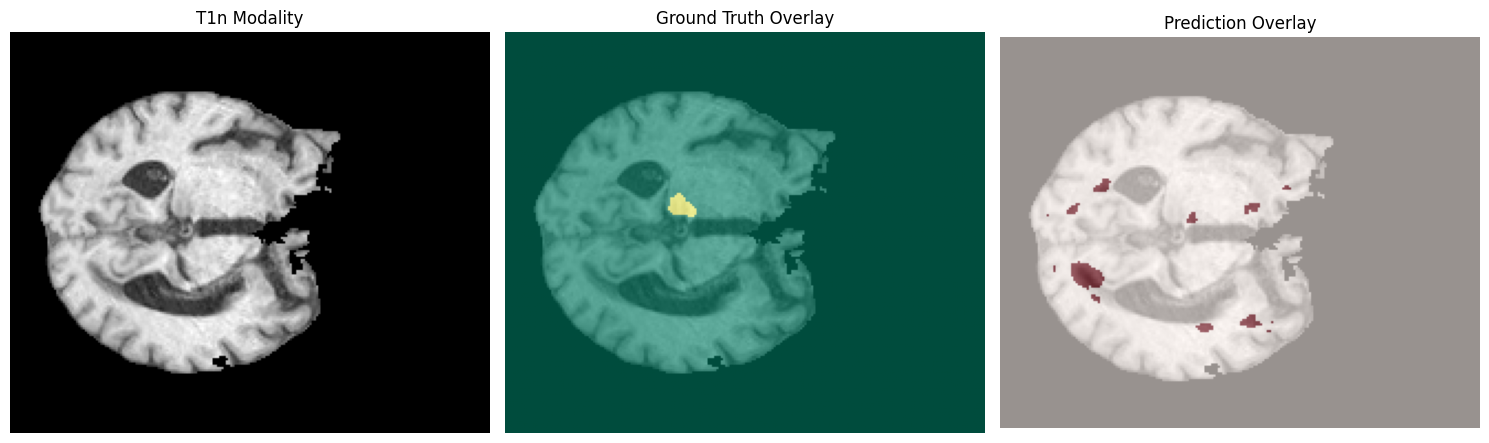

In [24]:
visualize_prediction(model, 'BraTS-GLI-02631-101', slice_index=80)

In [27]:
evaluate_prediction_metrics(model, 'BraTS-GLI-02631-101', slice_index=80)

📊 Dice Similarity Coefficient (DSC): 0.0048
📏 95th Percentile Hausdorff Distance (HD95): 57.92 pixels
🔍 Recall / Sensitivity: 0.0111


(np.float64(0.0047505938241151876),
 np.float64(57.919275860508776),
 np.float64(0.011111111109876544))

In [28]:
def evaluate_all_patients(model, slice_index=80, threshold=0.05, output_csv='evaluation_results_24.csv'):
    import csv
    results = []

    for patient_id in os.listdir(BASE_DIR):
        folder_path = os.path.join(BASE_DIR, patient_id)
        if os.path.isdir(folder_path) and patient_id.startswith("BraTS-GLI-"):
            try:
                print(f"Evaluating {patient_id}...")
                dsc, hd, recall = evaluate_prediction_metrics(model, patient_id, slice_index, threshold)
                results.append([patient_id, dsc, hd, recall])
            except Exception as e:
                print(f"Failed to evaluate {patient_id}: {e}")
                results.append([patient_id, None, None, None])

    with open(output_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['patient_id', 'dsc', 'hd95', 'recall'])
        for row in results:
            writer.writerow(row)

    print(f"\nEvaluation complete. Results saved to {output_csv}")

In [29]:
evaluate_all_patients(model)

Evaluating BraTS-GLI-02799-100...
📊 Dice Similarity Coefficient (DSC): 0.4316
📏 95th Percentile Hausdorff Distance (HD95): 34.33 pixels
🔍 Recall / Sensitivity: 0.3139
Evaluating BraTS-GLI-00472-100...
📊 Dice Similarity Coefficient (DSC): 0.0000
📏 95th Percentile Hausdorff Distance (HD95): nan pixels
🔍 Recall / Sensitivity: 0.0000
Evaluating BraTS-GLI-02916-100...
📊 Dice Similarity Coefficient (DSC): 0.0000
📏 95th Percentile Hausdorff Distance (HD95): 74.18 pixels
🔍 Recall / Sensitivity: 0.0000
Evaluating BraTS-GLI-02740-100...
📊 Dice Similarity Coefficient (DSC): 0.6045
📏 95th Percentile Hausdorff Distance (HD95): 51.30 pixels
🔍 Recall / Sensitivity: 0.8907
Evaluating BraTS-GLI-02093-109...
📊 Dice Similarity Coefficient (DSC): 0.5600
📏 95th Percentile Hausdorff Distance (HD95): 10.02 pixels
🔍 Recall / Sensitivity: 0.5490
Evaluating BraTS-GLI-02849-100...
📊 Dice Similarity Coefficient (DSC): 0.5149
📏 95th Percentile Hausdorff Distance (HD95): 13.00 pixels
🔍 Recall / Sensitivity: 0.4034
